<h1> Lab 2, Task 3, Sverdlyk Ivan, FB-51mp </h1>

In [1]:
# Імпорт бібліотек
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
#### Завантажив та переглянув датасет
df = pd.read_csv("YoutubeCommentsDataSet.csv")
print("\n First 5 rows")
print(df.head(5))
print("\n General information about DataFrame heart.csv:")
print(df.info())
print("\n Shape of DataFrame:")
print(df.shape)
print("\n List of Columns:")
print(df.columns)


 First 5 rows
                                             Comment Sentiment
0  lets not forget that apple pay in 2014 require...   neutral
1  here in nz 50 of retailers don’t even have con...  negative
2  i will forever acknowledge this channel with t...  positive
3  whenever i go to a place that doesn’t take app...  negative
4  apple pay is so convenient secure and easy to ...  positive

 General information about DataFrame heart.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18408 entries, 0 to 18407
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Comment    18364 non-null  object
 1   Sentiment  18408 non-null  object
dtypes: object(2)
memory usage: 287.8+ KB
None

 Shape of DataFrame:
(18408, 2)

 List of Columns:
Index(['Comment', 'Sentiment'], dtype='object')


#### Передобробка даних

In [3]:
nltk.download('stopwords')
print("NLTK stopwords downloaded.")
stop_words = set(stopwords.words('english'))
print("Stop-words created.")
# Функція для очищення тексту
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()  # Нижніий регістр
    text = re.sub(r'[^\w\s]', '', text)  # Видалення пунктуації
    text = re.sub(r'\d+', '', text)  # Видалення чисел
    # Токенізація та видалення стоп-слів
    words = [word for word in text.split() if word not in stop_words]
    return ' '.join(words)
# Видалення рядків з пропусками
df = df.dropna(subset=['Comment', 'Sentiment'])
# Використання препроцесінгу
df['Processed_Comment'] = df['Comment'].apply(preprocess_text)
print("\nDataset after preprocessing (first 5 rows)")
df[['Sentiment', 'Processed_Comment']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


NLTK stopwords downloaded.
Stop-words created.

Dataset after preprocessing (first 5 rows)


,Sentiment,Processed_Comment
0,neutral,lets forget apple pay required brand new iphon...
1,negative,nz retailers dont even contactless credit card...
2,positive,forever acknowledge channel help lessons ideas...
3,negative,whenever go place doesnt take apple pay doesnt...
4,positive,apple pay convenient secure easy use used kore...


#### Візуалізація з WordCloud


Generating WordClouds


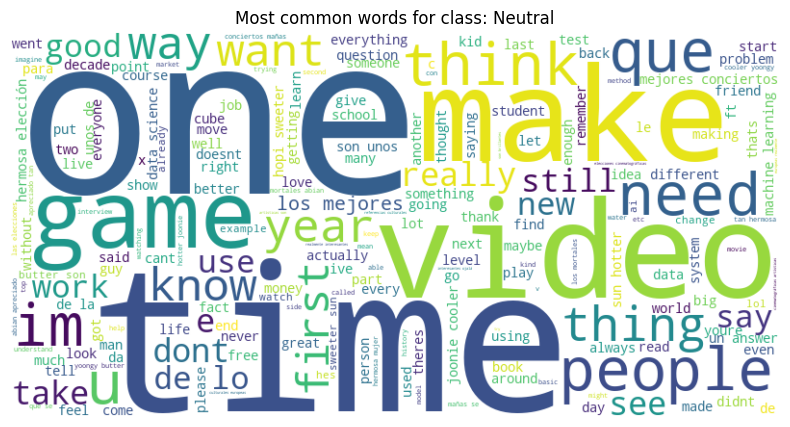

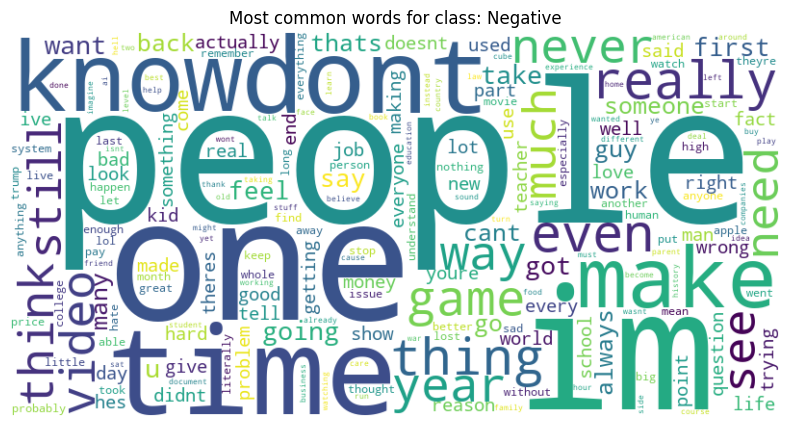

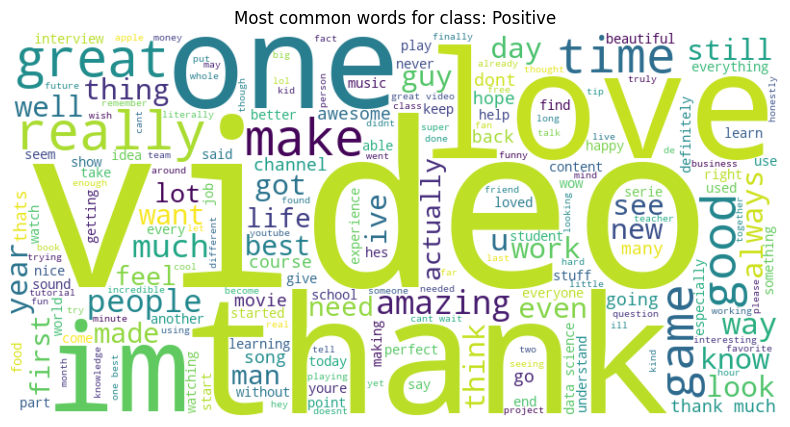

In [4]:
sentiments = df['Sentiment'].unique()
print("\nGenerating WordClouds")
for sentiment in sentiments:
    if pd.isna(sentiment):
        continue
    text_corpus = ' '.join(df[df['Sentiment'] == sentiment]['Processed_Comment'])
    if not text_corpus.strip():
        print(f"No data to generate word cloud for class: {sentiment}")
        continue
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_corpus)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Most common words for class: {sentiment.capitalize()}')
    plt.axis('off')
    plt.show() 

#### Векторизація TF-IDF

In [5]:
# Визначення ознак та цільвої змінної
X = df['Processed_Comment']
y = df['Sentiment']
# Розподіл даних на тестувальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
# Ініціалізація TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
# Навчання векторизатора на тренувальних даних
X_train_vec = tfidf_vectorizer.fit_transform(X_train)
# Трансформація тестових даних
X_test_vec = tfidf_vectorizer.transform(X_test)
print("\n-Vectorization Complete")
print(f"Training sample shape (vectorized): {X_train_vec.shape}")
print(f"Test sample shape (vectorized): {X_test_vec.shape}")


-Vectorization Complete
Training sample shape (vectorized): (13773, 5000)
Test sample shape (vectorized): (4591, 5000)


#### Навчання моделі та оцінка якості

In [6]:
# Ініціалізація моделі
base_model = LogisticRegression(solver='liblinear', random_state=42)
model = OneVsRestClassifier(base_model)
# Тренування
model.fit(X_train_vec, y_train)
print("Model Training Complete")
y_pred = model.predict(X_test_vec)
# Оцінка якості
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=0)
print("\MODEL EVALUATION RESULTS")
print(f"Overall Accuracy: {accuracy:.2f}")
print("\nDetailed Classification Report:")
print(report)

Model Training Complete
\MODEL EVALUATION RESULTS
Overall Accuracy: 0.75

Detailed Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.26      0.38       584
     neutral       0.62      0.58      0.60      1156
    positive       0.79      0.92      0.85      2851

    accuracy                           0.75      4591
   macro avg       0.71      0.58      0.61      4591
weighted avg       0.74      0.75      0.73      4591

